# 📊 Análisis exploratorio de datos (EDA)

## 🎯 Objectivo
Comprender la estructura y el comportamiento de los datos de ventas de Corporación Favorita

Este notebook se centra en:
- Explorar las variables principales y la estructura de datos
- Identificar valores faltantes y anomalías
- Analizar los patrones de ventas a lo largo del tiempo (tendencias diarias, semanales y estacionales)
- Comprender el comportamiento de las tiendas y las familias de productos
- Detectar posibles relaciones e información relevante para la ingeniería de características

El objetivo es desarrollar una sólida intuición sobre el conjunto de datos antes de realizar el modelado.

### Importar librerias

In [1]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns

In [2]:
!pip install lightgbm
import lightgbm as lgb
from sklearn.model_selection import TimeSeriesSplit

In [3]:
from sklearn.metrics import mean_squared_log_error

### Exploracion de Datos

In [4]:
train_df = pd.read_csv('train.csv')

In [5]:
train_df.describe()

,id,store_nbr,sales,onpromotion
count,3.000888e+06,3.000888e+06,3.000888e+06,3.000888e+06
mean,1.500444e+06,2.750000e+01,3.577757e+02,2.602770e+00
std,8.662819e+05,1.558579e+01,1.101998e+03,1.221888e+01
min,0.000000e+00,1.000000e+00,0.000000e+00,0.000000e+00
25%,7.502218e+05,1.400000e+01,0.000000e+00,0.000000e+00
50%,1.500444e+06,2.750000e+01,1.100000e+01,0.000000e+00
75%,2.250665e+06,4.100000e+01,1.958473e+02,0.000000e+00
max,3.000887e+06,5.400000e+01,1.247170e+05,7.410000e+02


In [6]:
train_df.shape

(3000888, 6)

In [7]:
train_df.info()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 3000888 entries, 0 to 3000887
Data columns (total 6 columns):
 #   Column       Dtype  
---  ------       -----  
 0   id           int64  
 1   date         object 
 2   store_nbr    int64  
 3   family       object 
 4   sales        float64
 5   onpromotion  int64  
dtypes: float64(1), int64(3), object(2)
memory usage: 137.4+ MB


In [8]:
train_df.columns

Index(['id', 'date', 'store_nbr', 'family', 'sales', 'onpromotion'], dtype='object')

In [9]:
train_df.head()

,id,date,store_nbr,family,sales,onpromotion
0,0,2013-01-01,1,AUTOMOTIVE,0.0,0
1,1,2013-01-01,1,BABY CARE,0.0,0
2,2,2013-01-01,1,BEAUTY,0.0,0
3,3,2013-01-01,1,BEVERAGES,0.0,0
4,4,2013-01-01,1,BOOKS,0.0,0


In [10]:
train_df['date'] = pd.to_datetime(train_df['date'])

In [11]:
train_df.info()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 3000888 entries, 0 to 3000887
Data columns (total 6 columns):
 #   Column       Dtype         
---  ------       -----         
 0   id           int64         
 1   date         datetime64[ns]
 2   store_nbr    int64         
 3   family       object        
 4   sales        float64       
 5   onpromotion  int64         
dtypes: datetime64[ns](1), float64(1), int64(3), object(1)
memory usage: 137.4+ MB


In [12]:
train_df.isnull().sum().sort_values(ascending=False)

id             0
date           0
store_nbr      0
family         0
sales          0
onpromotion    0
dtype: int64

In [13]:
train_df['date'].max()

Timestamp('2017-08-15 00:00:00')

In [14]:
train_df['date'].min()

Timestamp('2013-01-01 00:00:00')

In [15]:
train_df['store_nbr'].nunique()

54

In [16]:
train_df['family'].nunique()

33

In [17]:
stores_df = pd.read_csv('stores.csv')

In [18]:
stores_df.head()

,store_nbr,city,state,type,cluster
0,1,Quito,Pichincha,D,13
1,2,Quito,Pichincha,D,13
2,3,Quito,Pichincha,D,8
3,4,Quito,Pichincha,D,9
4,5,Santo Domingo,Santo Domingo de los Tsachilas,D,4


In [19]:
stores_df.isnull().sum().sort_values(ascending=False)

store_nbr    0
city         0
state        0
type         0
cluster      0
dtype: int64

In [20]:
holidays_df = pd.read_csv('holidays_events.csv')

In [21]:
holidays_df.isnull().sum().sort_values(ascending=False)

date           0
type           0
locale         0
locale_name    0
description    0
transferred    0
dtype: int64

In [22]:
holidays_df.head()

,date,type,locale,locale_name,description,transferred
0,2012-03-02,Holiday,Local,Manta,Fundacion de Manta,False
1,2012-04-01,Holiday,Regional,Cotopaxi,Provincializacion de Cotopaxi,False
2,2012-04-12,Holiday,Local,Cuenca,Fundacion de Cuenca,False
3,2012-04-14,Holiday,Local,Libertad,Cantonizacion de Libertad,False
4,2012-04-21,Holiday,Local,Riobamba,Cantonizacion de Riobamba,False


In [23]:
holidays_df.shape

(350, 6)

In [24]:
holidays_df['type'].value_counts()

type
Holiday       221
Event          56
Additional     51
Transfer       12
Bridge          5
Work Day        5
Name: count, dtype: int64

In [25]:
holidays_df['locale_name'].value_counts()

locale_name
Ecuador                           174
Quito                              13
Guaranda                           12
Riobamba                           12
Latacunga                          12
Ambato                             12
Guayaquil                          11
Cuenca                              7
Ibarra                              7
Imbabura                            6
Cotopaxi                            6
Libertad                            6
Manta                               6
Puyo                                6
El Carmen                           6
Machala                             6
Cayambe                             6
Esmeraldas                          6
Santo Domingo                       6
Quevedo                             6
Santa Elena                         6
Santo Domingo de los Tsachilas      6
Loja                                6
Salinas                             6
Name: count, dtype: int64

In [26]:
oil_df = pd.read_csv('oil.csv')

In [27]:
oil_df.isnull().sum().sort_values(ascending=False)

dcoilwtico    43
date           0
dtype: int64

In [28]:
oil_df.head()

,date,dcoilwtico
0,2013-01-01,NaN
1,2013-01-02,93.14
2,2013-01-03,92.97
3,2013-01-04,93.12
4,2013-01-07,93.20


In [29]:
submission_df = pd.read_csv('sample_submission.csv')

In [30]:
submission_df.isnull().sum().sort_values(ascending=False)

id       0
sales    0
dtype: int64

In [31]:
submission_df.head()

,id,sales
0,3000888,0.0
1,3000889,0.0
2,3000890,0.0
3,3000891,0.0
4,3000892,0.0


In [32]:
test_df = pd.read_csv('test.csv')

In [33]:
test_df.isnull().sum().sort_values(ascending=False)

id             0
date           0
store_nbr      0
family         0
onpromotion    0
dtype: int64

In [34]:
test_df.head()

,id,date,store_nbr,family,onpromotion
0,3000888,2017-08-16,1,AUTOMOTIVE,0
1,3000889,2017-08-16,1,BABY CARE,0
2,3000890,2017-08-16,1,BEAUTY,2
3,3000891,2017-08-16,1,BEVERAGES,20
4,3000892,2017-08-16,1,BOOKS,0


In [35]:
transactions_df = pd.read_csv('transactions.csv')

In [36]:
transactions_df.isnull().sum().sort_values(ascending=False)

date            0
store_nbr       0
transactions    0
dtype: int64

In [37]:
transactions_df.head()

,date,store_nbr,transactions
0,2013-01-01,25,770
1,2013-01-02,1,2111
2,2013-01-02,2,2358
3,2013-01-02,3,3487
4,2013-01-02,4,1922


In [38]:
ventas_diarias = train_df.groupby(train_df['date'].dt.date)['sales'].sum()

In [39]:
ventas_diarias

date
2013-01-01      2511.618999
2013-01-02    496092.417944
2013-01-03    361461.231124
2013-01-04    354459.677093
2013-01-05    477350.121229
                  ...      
2017-08-11    826373.722022
2017-08-12    792630.535079
2017-08-13    865639.677471
2017-08-14    760922.406081
2017-08-15    762661.935939
Name: sales, Length: 1684, dtype: float64

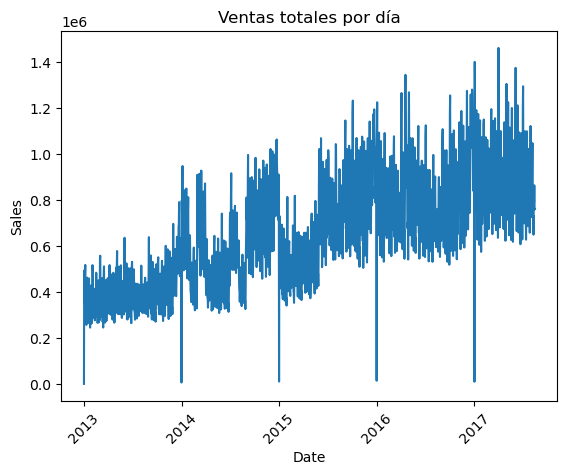

In [40]:
ventas_diarias.plot()
plt.title("Ventas totales por día")
plt.xlabel("Date")
plt.ylabel("Sales")
plt.xticks(rotation=45)
plt.show()

In [41]:
train_df['dayofweek'] = train_df['date'].dt.day_name()
ventas_semana = train_df.groupby('dayofweek')['sales'].mean()
print(ventas_semana)

dayofweek
Friday       325.238138
Monday       346.544732
Saturday     433.336472
Sunday       463.085366
Thursday     283.540517
Tuesday      319.823843
Wednesday    332.909401
Name: sales, dtype: float64


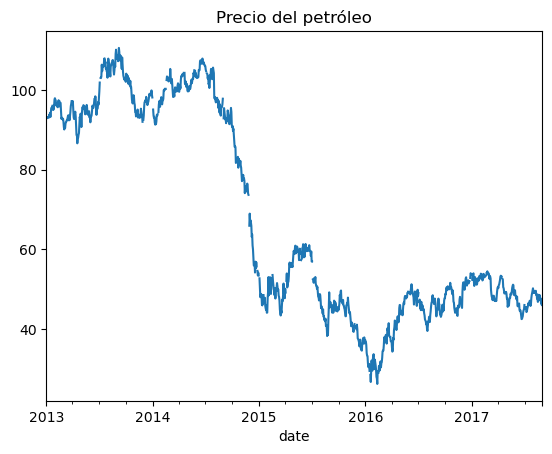

In [42]:
# Exploración A — Sobre el petróleo:
oil_df['date'] = pd.to_datetime(oil_df['date'])
oil_df.set_index('date')['dcoilwtico'].plot()
plt.title("Precio del petróleo")
plt.show()

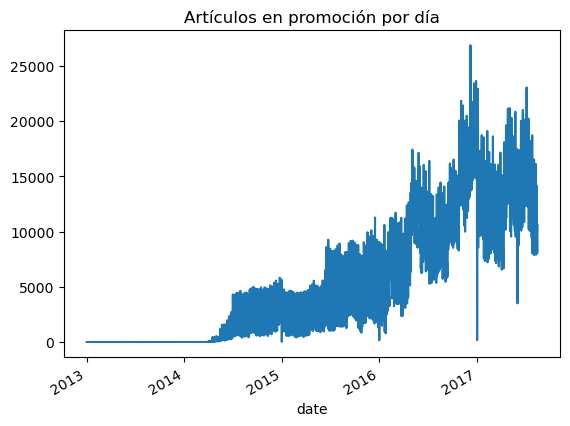

In [43]:
# Exploración B — Sobre promociones:
train_df.groupby('date')['onpromotion'].sum().plot()
plt.title("Artículos en promoción por día")
plt.show()

### Limpieza de datos

In [44]:
# Resolver nulos del petróleo
oil_df['dcoilwtico'] = oil_df['dcoilwtico'].ffill().bfill()

In [45]:
oil_df.isnull().sum().sort_values(ascending=False)

date          0
dcoilwtico    0
dtype: int64

# ⚙️ Feature Engineering

## 🎯 Objetivo
Crear características significativas para mejorar el rendimiento de los forecasting models.

Este notebook se centra en:
- Generar características basadas en el tiempo (día de la semana, mes, festivos)
- Crear lag features (ventas anteriores: t-1, t-7, t-14)
- Construir estadísticas móviles (promedios móviles, tendencias)
- Incorporar datos externos (festivos, promociones)
- Transformar y codificar variables para el modelado

El objetivo es transformar los datos brutos en un conjunto de datos estructurado adecuado para modelos de machine learning.

### Preparación de datos

In [46]:
# Merge de datasets relevantes
df_merge = train_df.merge(oil_df, on='date', how='left')\
             .merge(stores_df, on='store_nbr', how='left')

In [47]:
df_merge.head()

,id,date,store_nbr,family,sales,onpromotion,dayofweek,dcoilwtico,city,state,type,cluster
0,0,2013-01-01,1,AUTOMOTIVE,0.0,0,Tuesday,93.14,Quito,Pichincha,D,13
1,1,2013-01-01,1,BABY CARE,0.0,0,Tuesday,93.14,Quito,Pichincha,D,13
2,2,2013-01-01,1,BEAUTY,0.0,0,Tuesday,93.14,Quito,Pichincha,D,13
3,3,2013-01-01,1,BEVERAGES,0.0,0,Tuesday,93.14,Quito,Pichincha,D,13
4,4,2013-01-01,1,BOOKS,0.0,0,Tuesday,93.14,Quito,Pichincha,D,13


In [48]:
df_merge.shape

(3000888, 12)

In [49]:
# Tratar el dataset de feriados
holidays_df['date'] = pd.to_datetime(holidays_df['date'])

In [50]:
holidays_df.info()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 350 entries, 0 to 349
Data columns (total 6 columns):
 #   Column       Non-Null Count  Dtype         
---  ------       --------------  -----         
 0   date         350 non-null    datetime64[ns]
 1   type         350 non-null    object        
 2   locale       350 non-null    object        
 3   locale_name  350 non-null    object        
 4   description  350 non-null    object        
 5   transferred  350 non-null    bool          
dtypes: bool(1), datetime64[ns](1), object(4)
memory usage: 14.1+ KB


In [51]:
holidays_df['transferred'].value_counts(normalize=True)

transferred
False    0.965714
True     0.034286
Name: proportion, dtype: float64

In [52]:
holidays_df.head()

,date,type,locale,locale_name,description,transferred
0,2012-03-02,Holiday,Local,Manta,Fundacion de Manta,False
1,2012-04-01,Holiday,Regional,Cotopaxi,Provincializacion de Cotopaxi,False
2,2012-04-12,Holiday,Local,Cuenca,Fundacion de Cuenca,False
3,2012-04-14,Holiday,Local,Libertad,Cantonizacion de Libertad,False
4,2012-04-21,Holiday,Local,Riobamba,Cantonizacion de Riobamba,False


In [53]:
holiday_dates = holidays_df[holidays_df['transferred'] == False]['date']
df_merge['is_holiday'] = df_merge['date'].isin(holiday_dates).astype(int)

In [54]:
df_merge.head()

,id,date,store_nbr,family,sales,onpromotion,dayofweek,dcoilwtico,city,state,type,cluster,is_holiday
0,0,2013-01-01,1,AUTOMOTIVE,0.0,0,Tuesday,93.14,Quito,Pichincha,D,13,1
1,1,2013-01-01,1,BABY CARE,0.0,0,Tuesday,93.14,Quito,Pichincha,D,13,1
2,2,2013-01-01,1,BEAUTY,0.0,0,Tuesday,93.14,Quito,Pichincha,D,13,1
3,3,2013-01-01,1,BEVERAGES,0.0,0,Tuesday,93.14,Quito,Pichincha,D,13,1
4,4,2013-01-01,1,BOOKS,0.0,0,Tuesday,93.14,Quito,Pichincha,D,13,1


In [55]:
# Crear features engineer a las fechas
df_merge['month'] = df_merge['date'].dt.month
df_merge['day_of_week'] = df_merge['date'].dt.day_of_week  #  0=lunes a 6=domingo
df_merge['week_of_year'] = df_merge['date'].dt.isocalendar().week
df_merge['is_weekend'] = df_merge['day_of_week'] >= 5
df_merge['year'] = df_merge['date'].dt.year

In [56]:
df_merge.head()

,id,date,store_nbr,family,sales,onpromotion,dayofweek,dcoilwtico,city,state,type,cluster,is_holiday,month,day_of_week,week_of_year,is_weekend,year
0,0,2013-01-01,1,AUTOMOTIVE,0.0,0,Tuesday,93.14,Quito,Pichincha,D,13,1,1,1,1,False,2013
1,1,2013-01-01,1,BABY CARE,0.0,0,Tuesday,93.14,Quito,Pichincha,D,13,1,1,1,1,False,2013
2,2,2013-01-01,1,BEAUTY,0.0,0,Tuesday,93.14,Quito,Pichincha,D,13,1,1,1,1,False,2013
3,3,2013-01-01,1,BEVERAGES,0.0,0,Tuesday,93.14,Quito,Pichincha,D,13,1,1,1,1,False,2013
4,4,2013-01-01,1,BOOKS,0.0,0,Tuesday,93.14,Quito,Pichincha,D,13,1,1,1,1,False,2013


### Feature Engineering

In [57]:
# rolling de 7 dias para onpromotion 
df_merge['promo_rolling_7'] = df_merge.groupby(['store_nbr', 'family'])['onpromotion']\
                          .transform(lambda x: x.rolling(7).mean())

In [58]:
# lag de 7, 14 y 21 dias para las ventas
for lag in [7, 14, 28]:
    df_merge[f'sales_lag{lag}'] = df_merge.groupby(['store_nbr', 'family'])['sales']\
                              .transform(lambda x: x.shift(lag))

In [59]:
# lag de rolling mean de 7 y 14 dias para las ventas
for window in [7, 14]:
    df_merge[f'sales_rolling{window}'] = df_merge.groupby(['store_nbr', 'family'])['sales']\
                                     .transform(lambda x: x.shift(1).rolling(window).mean())

In [60]:
df_merge.head()

,id,date,store_nbr,family,sales,onpromotion,dayofweek,dcoilwtico,city,state,...,day_of_week,week_of_year,is_weekend,year,promo_rolling_7,sales_lag7,sales_lag14,sales_lag28,sales_rolling7,sales_rolling14
0,0,2013-01-01,1,AUTOMOTIVE,0.0,0,Tuesday,93.14,Quito,Pichincha,...,1,1,False,2013,NaN,NaN,NaN,NaN,NaN,NaN
1,1,2013-01-01,1,BABY CARE,0.0,0,Tuesday,93.14,Quito,Pichincha,...,1,1,False,2013,NaN,NaN,NaN,NaN,NaN,NaN
2,2,2013-01-01,1,BEAUTY,0.0,0,Tuesday,93.14,Quito,Pichincha,...,1,1,False,2013,NaN,NaN,NaN,NaN,NaN,NaN
3,3,2013-01-01,1,BEVERAGES,0.0,0,Tuesday,93.14,Quito,Pichincha,...,1,1,False,2013,NaN,NaN,NaN,NaN,NaN,NaN
4,4,2013-01-01,1,BOOKS,0.0,0,Tuesday,93.14,Quito,Pichincha,...,1,1,False,2013,NaN,NaN,NaN,NaN,NaN,NaN


In [61]:
df_merge.shape

(3000888, 24)

# 🤖 Modeling and Hyperparameter Tuning

## 🎯 Objetivo
Entrenar, evaluar y optimizar modelos de pronóstico para predecir ventas futuras.

Este cuaderno se centra en:
- Dividir los datos en conjuntos de entrenamiento y validación (división con consideración temporal)
- Entrenar modelos de Machine Learning
- Evaluar el rendimiento del modelo utilizando métricas apropiadas (RMSLE)
- Realizar el ajuste de hiperparámetros para mejorar los resultados
- Comparar las versiones del modelo y seleccionar el enfoque con mejor rendimiento

El objetivo es construir un modelo de pronóstico robusto y confiable para la predicción de ventas en tiendas.

### Selección y entrenamiento del modelo

In [62]:
# Eliminar valores nulos de las nuevas columnas creadas en feature engineering
df_merge.dropna(subset=['sales_lag7', 'sales_lag14', 'sales_lag28'], inplace=True)

In [63]:
df_merge.shape

(2950992, 24)

In [64]:
df_merge.head()

,id,date,store_nbr,family,sales,onpromotion,dayofweek,dcoilwtico,city,state,...,day_of_week,week_of_year,is_weekend,year,promo_rolling_7,sales_lag7,sales_lag14,sales_lag28,sales_rolling7,sales_rolling14
49896,49896,2013-01-29,1,AUTOMOTIVE,2.0,0,Tuesday,97.62,Quito,Pichincha,...,1,5,False,2013,0.0,1.0,1.0,0.0,2.571429,2.142857
49897,49897,2013-01-29,1,BABY CARE,0.0,0,Tuesday,97.62,Quito,Pichincha,...,1,5,False,2013,0.0,0.0,0.0,0.0,0.000000,0.000000
49898,49898,2013-01-29,1,BEAUTY,3.0,0,Tuesday,97.62,Quito,Pichincha,...,1,5,False,2013,0.0,1.0,0.0,0.0,0.571429,1.214286
49899,49899,2013-01-29,1,BEVERAGES,932.0,0,Tuesday,97.62,Quito,Pichincha,...,1,5,False,2013,0.0,1037.0,1149.0,0.0,884.571429,946.357143
49900,49900,2013-01-29,1,BOOKS,0.0,0,Tuesday,97.62,Quito,Pichincha,...,1,5,False,2013,0.0,0.0,0.0,0.0,0.000000,0.000000


In [65]:
# Definir features y target
cat_features = ['family', 'city', 'state', 'type', 'cluster']

In [66]:
# Convierte categóricas a tipo category
for col in cat_features:
    df_merge[col] = df_merge[col].astype('category')

In [67]:
df_merge.head()

,id,date,store_nbr,family,sales,onpromotion,dayofweek,dcoilwtico,city,state,...,day_of_week,week_of_year,is_weekend,year,promo_rolling_7,sales_lag7,sales_lag14,sales_lag28,sales_rolling7,sales_rolling14
49896,49896,2013-01-29,1,AUTOMOTIVE,2.0,0,Tuesday,97.62,Quito,Pichincha,...,1,5,False,2013,0.0,1.0,1.0,0.0,2.571429,2.142857
49897,49897,2013-01-29,1,BABY CARE,0.0,0,Tuesday,97.62,Quito,Pichincha,...,1,5,False,2013,0.0,0.0,0.0,0.0,0.000000,0.000000
49898,49898,2013-01-29,1,BEAUTY,3.0,0,Tuesday,97.62,Quito,Pichincha,...,1,5,False,2013,0.0,1.0,0.0,0.0,0.571429,1.214286
49899,49899,2013-01-29,1,BEVERAGES,932.0,0,Tuesday,97.62,Quito,Pichincha,...,1,5,False,2013,0.0,1037.0,1149.0,0.0,884.571429,946.357143
49900,49900,2013-01-29,1,BOOKS,0.0,0,Tuesday,97.62,Quito,Pichincha,...,1,5,False,2013,0.0,0.0,0.0,0.0,0.000000,0.000000


In [68]:
df_merge.info()

<class 'pandas.core.frame.DataFrame'>
Index: 2950992 entries, 49896 to 3000887
Data columns (total 24 columns):
 #   Column           Dtype         
---  ------           -----         
 0   id               int64         
 1   date             datetime64[ns]
 2   store_nbr        int64         
 3   family           category      
 4   sales            float64       
 5   onpromotion      int64         
 6   dayofweek        object        
 7   dcoilwtico       float64       
 8   city             category      
 9   state            category      
 10  type             category      
 11  cluster          category      
 12  is_holiday       int64         
 13  month            int32         
 14  day_of_week      int32         
 15  week_of_year     UInt32        
 16  is_weekend       bool          
 17  year             int32         
 18  promo_rolling_7  float64       
 19  sales_lag7       float64       
 20  sales_lag14      float64       
 21  sales_lag28      float64       


In [69]:
# Definir X e y
features = ['store_nbr', 'family', 'onpromotion', 'dcoilwtico',
            'city', 'state', 'type', 'cluster', 'is_holiday',
            'month', 'day_of_week', 'week_of_year', 'is_weekend',
            'year', 'promo_rolling_7', 'sales_lag7', 
            'sales_lag14', 'sales_lag28', 
            'sales_rolling7', 'sales_rolling14']

X = df_merge[features]
y = df_merge['sales']

In [70]:
# split de validación
# Usamos las últimas 15 semanas como validación
# (mismo horizonte que el test real)
cutoff_date = '2017-04-30'

X_train = X[df_merge['date'] <= cutoff_date]
y_train = y[df_merge['date'] <= cutoff_date]

X_val = X[df_merge['date'] > cutoff_date]
y_val = y[df_merge['date'] > cutoff_date]

In [71]:
model = lgb.LGBMRegressor(
    n_estimators=1000,
    learning_rate=0.05,
    num_leaves=31,
    random_state=42
)

model.fit(
    X_train, y_train,
    eval_set=[(X_val, y_val)],
    callbacks=[lgb.early_stopping(50), 
               lgb.log_evaluation(100)]
)

[LightGBM] [Info] Auto-choosing row-wise multi-threading, the overhead of testing was 0.160314 seconds.
You can set `force_row_wise=true` to remove the overhead.
And if memory is not enough, you can set `force_col_wise=true`.
[LightGBM] [Info] Total Bins 2221
[LightGBM] [Info] Number of data points in the train set: 2760318, number of used features: 20
[LightGBM] [Info] Start training from score 352.167635
Training until validation scores don't improve for 50 rounds
[100]	valid_0's l2: 72373.9
[200]	valid_0's l2: 70377.9
[300]	valid_0's l2: 68694.1
[400]	valid_0's l2: 67553.1
Early stopping, best iteration is:
[430]	valid_0's l2: 67517


LGBMRegressor(learning_rate=0.05, n_estimators=1000, random_state=42)

In [72]:
# Genera predicciones
preds = model.predict(X_val)

In [73]:
# LightGBM puede predecir valores negativos
# RMSLE no acepta negativos, así que los clippeamos a 0
preds_clipped = np.clip(preds, 0, None)

In [74]:
# Calcula RMSLE (test)
rmsle = np.sqrt(mean_squared_log_error(y_val, preds_clipped))
print(f"RMSLE en validación: {rmsle:.4f}")

RMSLE en validación: 0.5221


In [75]:
# predicciones negativas (con clip)
len(preds_clipped[preds_clipped<0])

0

            feature  importance
11     week_of_year        2070
3        dcoilwtico        1428
18   sales_rolling7        1117
15       sales_lag7         960
17      sales_lag28         934
9             month         752
2       onpromotion         751
14  promo_rolling_7         743
10      day_of_week         741
16      sales_lag14         699


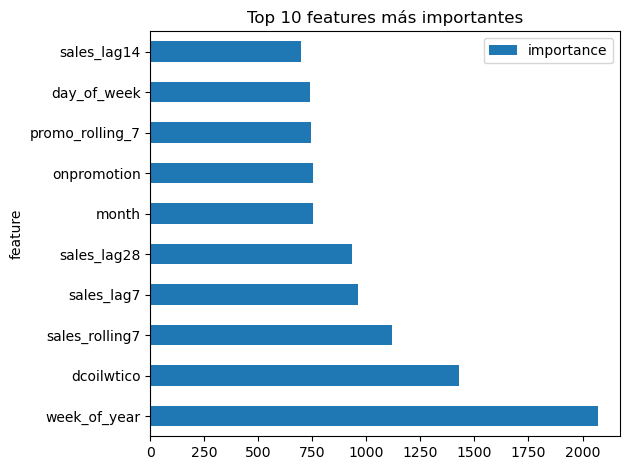

In [76]:
# features más importantes
importance = pd.DataFrame({
    'feature': features,
    'importance': model.feature_importances_
}).sort_values('importance', ascending=False)

print(importance.head(10))

importance.head(10).plot(
    kind='barh', 
    x='feature', 
    y='importance',
    title='Top 10 features más importantes'
)
plt.tight_layout()
plt.show()

### Model Tuning

In [77]:
# Calcula RMSLE (train)
preds_train = model.predict(X_train)
preds_train_clipped = np.clip(preds_train, 0, None)
rmsle_train = np.sqrt(mean_squared_log_error(y_train, preds_train_clipped))
print(f"RMSLE train: {rmsle_train:.4f}")
print(f"RMSLE val:   {0.5221:.4f}")
print(f"Diferencia:  {0.5221 - rmsle_train:.4f}")

RMSLE train: 0.7864
RMSLE val:   0.5221
Diferencia:  -0.2643


In [78]:
# tunear hacia más complejidad
model_v2 = lgb.LGBMRegressor(
    n_estimators=2000,
    learning_rate=0.03,
    num_leaves=64,
    min_child_samples=20,
    random_state=42
)

model_v2.fit(
    X_train, y_train,
    eval_set=[(X_val, y_val)],
    callbacks=[lgb.early_stopping(50),
               lgb.log_evaluation(100)]
)

[LightGBM] [Info] Auto-choosing row-wise multi-threading, the overhead of testing was 0.165062 seconds.
You can set `force_row_wise=true` to remove the overhead.
And if memory is not enough, you can set `force_col_wise=true`.
[LightGBM] [Info] Total Bins 2221
[LightGBM] [Info] Number of data points in the train set: 2760318, number of used features: 20
[LightGBM] [Info] Start training from score 352.167635
Training until validation scores don't improve for 50 rounds
[100]	valid_0's l2: 76166.2
[200]	valid_0's l2: 67257.4
[300]	valid_0's l2: 66215.3
[400]	valid_0's l2: 65611.2
Early stopping, best iteration is:
[437]	valid_0's l2: 65392.3


LGBMRegressor(learning_rate=0.03, n_estimators=2000, num_leaves=64,
              random_state=42)

In [79]:
# Genera predicciones v2
preds_v2 = model_v2.predict(X_val)

In [80]:
# LightGBM puede predecir valores negativos
# RMSLE no acepta negativos, así que los clippeamos a 0
preds_clipped_v2 = np.clip(preds_v2, 0, None)

In [81]:
# revisión predicciones negativas (con clip)
len(preds_clipped_v2[preds_clipped_v2<0])

0

In [82]:
# Calcula RMSLE_v2 (test)
rmsle_v2 = np.sqrt(mean_squared_log_error(y_val, preds_clipped_v2))
print(f"RMSLE en validación: {rmsle_v2:.4f}")

RMSLE en validación: 0.5061


In [83]:
# agregaremos features que nos pueden ayudar para el modelo
# 15 días después
df_merge['sales_lag15'] = df_merge.groupby(['store_nbr', 'family'], observed=True)['sales']\
                      .transform(lambda x: x.shift(15))
# Mismo día del año pasado
df_merge['sales_lag365'] = df_merge.groupby(['store_nbr', 'family'], observed=True)['sales']\
                       .transform(lambda x: x.shift(365))

# Mismo día hace 2 semanas exactas
df_merge['sales_lag16'] = df_merge.groupby(['store_nbr', 'family'], observed=True)['sales']\
                       .transform(lambda x: x.shift(16))

In [84]:
# Actualizar la lista de features
features = features + ['sales_lag15', 'sales_lag16', 'sales_lag365']

In [85]:
# Eliminar nulos nuevos generados
df_merge.dropna(subset=['sales_lag365'], inplace=True)

In [86]:
# Reconstruir X e y
X = df_merge[features]
y = df_merge['sales']

In [87]:
# split de validación
# Usamos las últimas 15 semanas como validación
# (mismo horizonte que el test real)
cutoff_date = '2017-04-30'

X_train = X[df_merge['date'] <= cutoff_date]
y_train = y[df_merge['date'] <= cutoff_date]

X_val = X[df_merge['date'] > cutoff_date]
y_val = y[df_merge['date'] > cutoff_date]

In [88]:
# Re-entrenar el modelo
model_v3 = lgb.LGBMRegressor(
    n_estimators=2000,
    learning_rate=0.03,
    num_leaves=64,
    min_child_samples=20,
    random_state=42
)

model_v3.fit(
    X_train, y_train,
    eval_set=[(X_val, y_val)],
    callbacks=[lgb.early_stopping(50),
               lgb.log_evaluation(100)]
)

[LightGBM] [Info] Auto-choosing col-wise multi-threading, the overhead of testing was 0.379773 seconds.
You can set `force_col_wise=true` to remove the overhead.
[LightGBM] [Info] Total Bins 3023
[LightGBM] [Info] Number of data points in the train set: 2109888, number of used features: 23
[LightGBM] [Info] Start training from score 390.205208
Training until validation scores don't improve for 50 rounds
[100]	valid_0's l2: 75507.3
[200]	valid_0's l2: 67927
[300]	valid_0's l2: 66273.8
[400]	valid_0's l2: 66010.3
[500]	valid_0's l2: 65823.1
[600]	valid_0's l2: 65014
[700]	valid_0's l2: 64738.1
Early stopping, best iteration is:
[747]	valid_0's l2: 64626.1


LGBMRegressor(learning_rate=0.03, n_estimators=2000, num_leaves=64,
              random_state=42)

In [89]:
# Genera predicciones v2
preds_v3 = model_v3.predict(X_val)

In [90]:
# LightGBM puede predecir valores negativos
# RMSLE no acepta negativos, así que los clippeamos a 0
preds_clipped_v3 = np.clip(preds_v3, 0, None)

In [91]:
# revisión predicciones negativas (con clip)
len(preds_clipped_v3[preds_clipped_v3<0])

0

In [92]:
# Calcula RMSLE_v2 (test)
rmsle_v3 = np.sqrt(mean_squared_log_error(y_val, preds_clipped_v3))
print(f"RMSLE en validación: {rmsle_v3:.4f}")

RMSLE en validación: 0.4850


            feature  importance
11     week_of_year        6259
3        dcoilwtico        5533
15       sales_lag7        2901
14  promo_rolling_7        2897
2       onpromotion        2871
22     sales_lag365        2868
18   sales_rolling7        2806
17      sales_lag28        2512
9             month        2416
10      day_of_week        2387


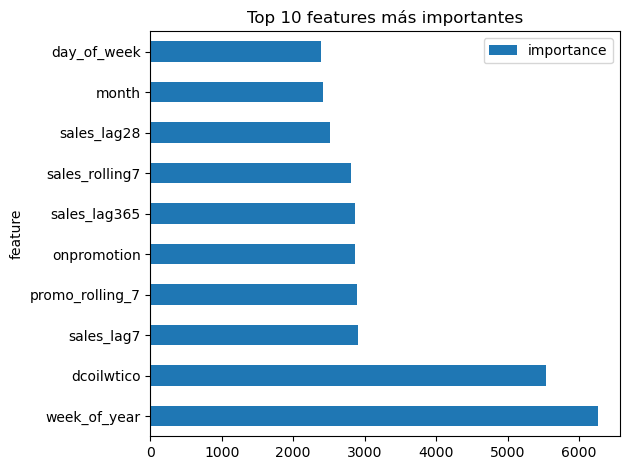

In [93]:
# features más importantes v2
importance = pd.DataFrame({
    'feature': features,
    'importance': model_v3.feature_importances_
}).sort_values('importance', ascending=False)

print(importance.head(10))

importance.head(10).plot(
    kind='barh', 
    x='feature', 
    y='importance',
    title='Top 10 features más importantes'
)
plt.tight_layout()
plt.show()

### Predicciones finales

In [94]:
test_df.head()

,id,date,store_nbr,family,onpromotion
0,3000888,2017-08-16,1,AUTOMOTIVE,0
1,3000889,2017-08-16,1,BABY CARE,0
2,3000890,2017-08-16,1,BEAUTY,2
3,3000891,2017-08-16,1,BEVERAGES,20
4,3000892,2017-08-16,1,BOOKS,0


In [95]:
# convertimos 'date' (test) en datetime
test_df['date'] = pd.to_datetime(test_df['date'])

In [96]:
# Tomar el historial reciente del train para calcular lags
# Necesito al menos 365 días hacia atrás
last_train = train_df[train_df['date'] >= '2016-08-16'].copy()

In [97]:
# Unir train reciente con test para calcular lags en contexto
full_df = pd.concat([last_train, test_df], sort=False)
full_df = full_df.sort_values(['store_nbr', 'family', 'date'])

In [98]:
full_df.shape

(677160, 7)

In [99]:
# Recalcula lags sobre el dataframe completo
for lag in [7, 14, 15, 16, 28, 365]:
    full_df[f'sales_lag{lag}'] = full_df.groupby(
        ['store_nbr', 'family'])['sales']\
        .transform(lambda x: x.shift(lag))

In [100]:
# Recalcular rolling means
for window in [7, 14]:
    full_df[f'sales_rolling{window}'] = full_df.groupby(
        ['store_nbr', 'family'])['sales']\
        .transform(lambda x: x.shift(1).rolling(window).mean())

In [101]:
# Extraer solo las filas del test
test_final = full_df[full_df['date'] > '2017-08-15'].copy()

In [102]:
test_final.head()

,id,date,store_nbr,family,sales,onpromotion,dayofweek,sales_lag7,sales_lag14,sales_lag15,sales_lag16,sales_lag28,sales_lag365,sales_rolling7,sales_rolling14
0,3000888,2017-08-16,1,AUTOMOTIVE,NaN,0,NaN,7.0,4.0,5.0,8.0,7.0,NaN,4.142857,4.714286
1782,3002670,2017-08-17,1,AUTOMOTIVE,NaN,0,NaN,9.0,3.0,4.0,5.0,4.0,5.0,NaN,NaN
3564,3004452,2017-08-18,1,AUTOMOTIVE,NaN,0,NaN,1.0,8.0,3.0,4.0,10.0,4.0,NaN,NaN
5346,3006234,2017-08-19,1,AUTOMOTIVE,NaN,0,NaN,6.0,5.0,8.0,3.0,8.0,6.0,NaN,NaN
7128,3008016,2017-08-20,1,AUTOMOTIVE,NaN,0,NaN,1.0,6.0,5.0,8.0,0.0,12.0,NaN,NaN


In [103]:
# Agrega features de fecha al test
test_final['month'] = test_final['date'].dt.month
test_final['day_of_week'] = test_final['date'].dt.dayofweek
test_final['week_of_year'] = test_final['date'].dt.isocalendar().week
test_final['is_weekend'] = test_final['day_of_week'] >= 5
test_final['year'] = test_final['date'].dt.year

In [104]:
# Merge con oil y stores
test_final = test_final.merge(oil_df, on='date', how='left')
test_final = test_final.merge(stores_df, on='store_nbr', how='left')

In [105]:
# Forward fill del petróleo por si hay nulos
test_final['dcoilwtico'] = test_final['dcoilwtico'].ffill()

In [106]:
# Agrega is_holiday
test_final['is_holiday'] = test_final['date'].isin(holiday_dates).astype(int)

In [107]:
# Encode categóricas
for col in cat_features:
    test_final[col] = test_final[col].astype('category')

In [108]:
test_final.head()

,id,date,store_nbr,family,sales,onpromotion,dayofweek,sales_lag7,sales_lag14,sales_lag15,...,day_of_week,week_of_year,is_weekend,year,dcoilwtico,city,state,type,cluster,is_holiday
0,3000888,2017-08-16,1,AUTOMOTIVE,NaN,0,NaN,7.0,4.0,5.0,...,2,33,False,2017,46.80,Quito,Pichincha,D,13,0
1,3002670,2017-08-17,1,AUTOMOTIVE,NaN,0,NaN,9.0,3.0,4.0,...,3,33,False,2017,47.07,Quito,Pichincha,D,13,0
2,3004452,2017-08-18,1,AUTOMOTIVE,NaN,0,NaN,1.0,8.0,3.0,...,4,33,False,2017,48.59,Quito,Pichincha,D,13,0
3,3006234,2017-08-19,1,AUTOMOTIVE,NaN,0,NaN,6.0,5.0,8.0,...,5,33,True,2017,48.59,Quito,Pichincha,D,13,0
4,3008016,2017-08-20,1,AUTOMOTIVE,NaN,0,NaN,1.0,6.0,5.0,...,6,33,True,2017,48.59,Quito,Pichincha,D,13,0


In [109]:
test_final['promo_rolling_7'] = test_final.groupby(['store_nbr', 'family'], observed=False)['onpromotion']\
                          .transform(lambda x: x.rolling(7).mean())

In [110]:
# Genera predicciones
X_test = test_final[features]
preds_test = model_v3.predict(X_test)
preds_test = np.clip(preds_test, 0, None)

In [111]:
submission_df.head()

,id,sales
0,3000888,0.0
1,3000889,0.0
2,3000890,0.0
3,3000891,0.0
4,3000892,0.0


In [112]:
# Verificar que los ids estén alineados con test_final
# antes de reemplazar
print(submission_df.shape)
print(test_final.shape)

(28512, 2)
(28512, 27)


In [113]:
# Reemplazar los ceros con tus predicciones
submission_df['sales'] = preds_test

In [114]:
# Verifica que no haya negativos
print(f"Negativos: {(submission_df['sales'] < 0).sum()}")
print(submission_df.head(10))

Negativos: 0
        id     sales
0  3000888  3.835810
1  3000889  0.620729
2  3000890  1.326189
3  3000891  1.326189
4  3000892  1.326189
5  3000893  1.741114
6  3000894  0.926132
7  3000895  0.926132
8  3000896  1.593164
9  3000897  1.326189


In [115]:
# Verificar el orden preds_test corresponde exactamente al orden de submission_df

# Crea un dataframe con ids y predicciones
preds_df = pd.DataFrame({
    'id': test_final['id'],
    'sales': preds_test
})

In [116]:
# Merge por id — así garantizas alineación perfecta
submission_final = submission_df[['id']].merge(preds_df, on='id', how='left')

In [117]:
# Verificaciones antes de guardar
print(f"Shape: {submission_final.shape}")
print(f"Nulos: {submission_final['sales'].isnull().sum()}")
print(f"Negativos: {(submission_final['sales'] < 0).sum()}")
print(f"IDs coinciden: {submission_final['id'].equals(submission_df['id'])}")
print(submission_final.head(10))

Shape: (28512, 2)
Nulos: 0
Negativos: 0
IDs coinciden: True
        id        sales
0  3000888     3.835810
1  3000889     0.926132
2  3000890     8.630884
3  3000891  2142.224294
4  3000892     0.926132
5  3000893   372.237311
6  3000894     6.378969
7  3000895   717.405279
8  3000896   801.881347
9  3000897   147.281362
